In [1]:
import pandas as pd
import re
from typing import List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# importing codebook
df_code = pd.read_csv('/Users/ramius/Desktop/CodeVault/01_Project/Work/Susumu/Student_Survey/StudentSurvey_WS2526/documentation/Student_Survey_Codebook_WS2526.csv', delimiter=";")
df_data = pd.read_csv('data_filtered.csv')

## Missing Values 

In [ ]:
# fill missing values with 0 for "social_media" columns
social_media_cols = [col for col in df_data.columns if re.search(r'social_networks', col)]
df_data[social_media_cols] = df_data[social_media_cols].fillna(0)

# # fill missing values with 0 for "social_media" columns
# social_media_cols = [col for col in df_data.columns if re.search(r'feedback', col)]
# df_data[social_media_cols] = df_data[social_media_cols].fillna("Missing")

# # fill missing values with 0 for "social_media" columns
# social_media_cols = [col for col in df_data.columns if re.search(r'network_narrative', col)]
# df_data[social_media_cols] = df_data[social_media_cols].fillna("Missing")

# # fill missing values with 0 for "social_media" columns
# social_media_cols = [col for col in df_data.columns if re.search(r'time_class', col)]
# df_data[social_media_cols] = df_data[social_media_cols].fillna(0)

# # fill missing values with 0 for "social_media" columns
# social_media_cols = [col for col in df_data.columns if re.search(r'time_work', col)]
# df_data[social_media_cols] = df_data[social_media_cols].fillna(0)

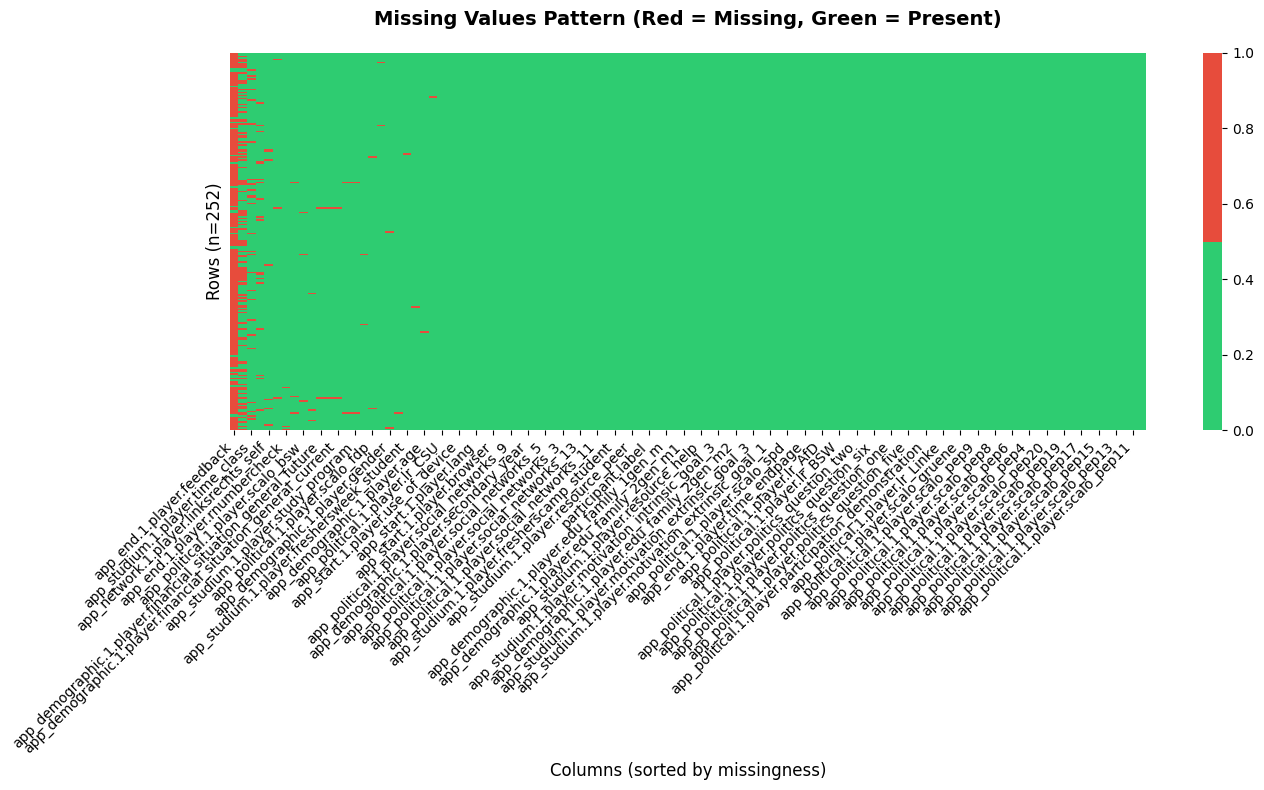

In [6]:
# Compact heatmap with column sorting by missingness
missing_cols = df_data.columns[df_data.isnull().any()].tolist()
df_missing_only = df_data

# Sort columns by percentage of missing values
sorted_cols = df_missing_only.isnull().sum().sort_values(ascending=False).index
df_sorted = df_missing_only[sorted_cols]

plt.figure(figsize=(14, 8))
sns.heatmap(df_sorted.isnull(), 
            yticklabels=False,
            cmap=['#2ecc71', '#e74c3c'],  # Green = present, Red = missing
            vmin=0, 
            vmax=1)
plt.title('Missing Values Pattern (Red = Missing, Green = Present)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Columns (sorted by missingness)', fontsize=12)
plt.ylabel(f'Rows (n={len(df_data)})', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

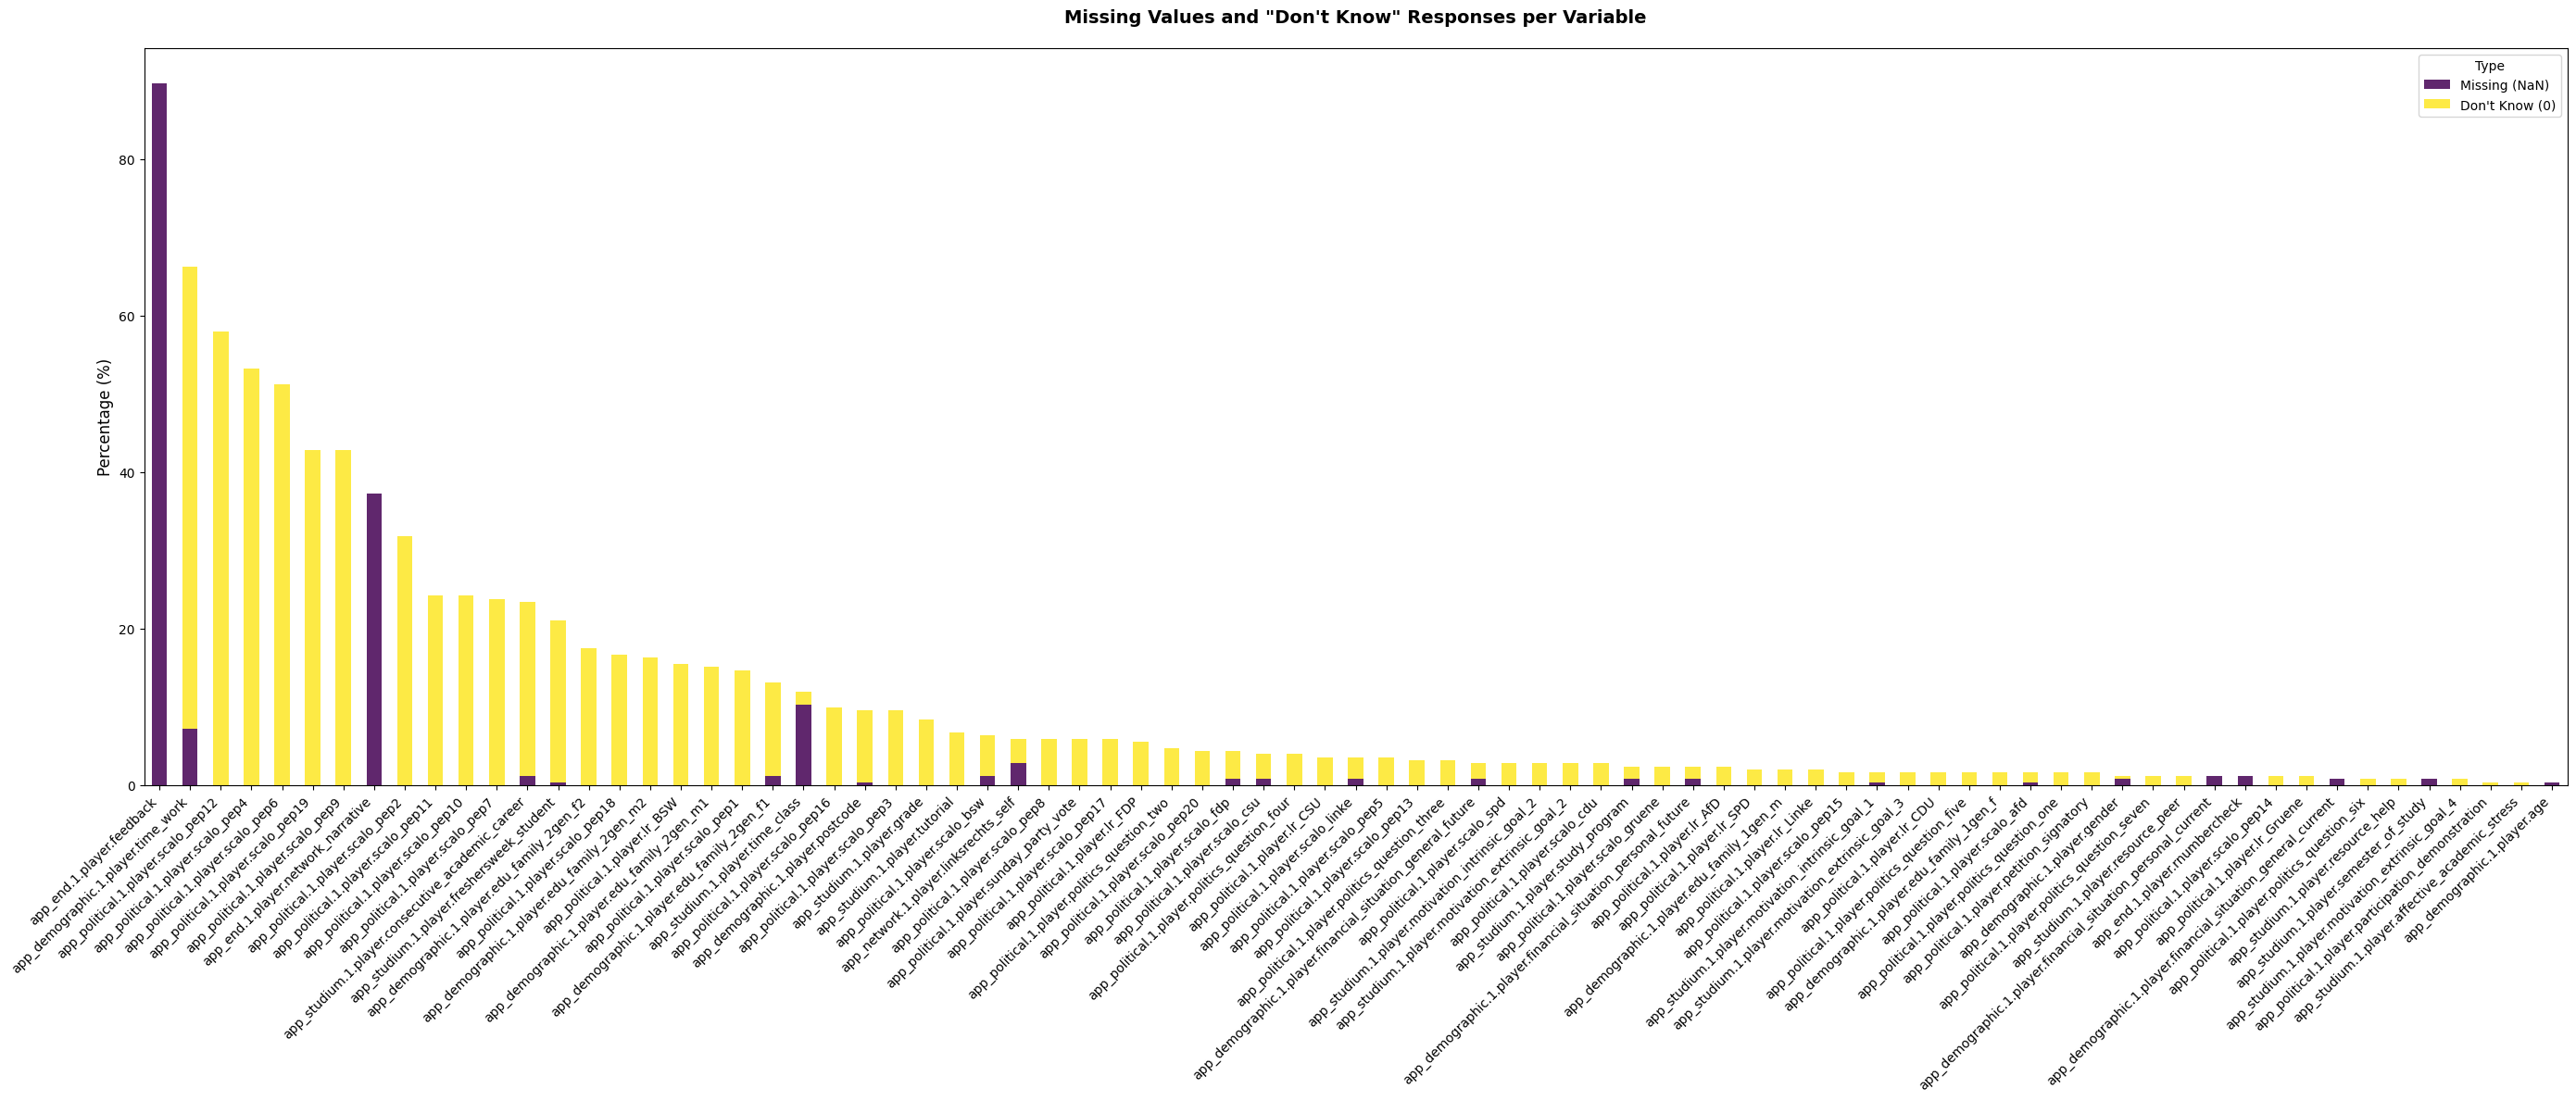


Columns with highest data quality issues:
app_end.1.player.feedback             89.682540
app_demographic.1.player.time_work    66.269841
app_political.1.player.scalo_pep12    57.936508
app_political.1.player.scalo_pep4     53.174603
app_political.1.player.scalo_pep6     51.190476
app_political.1.player.scalo_pep19    42.857143
app_political.1.player.scalo_pep9     42.857143
app_end.1.player.network_narrative    37.301587
app_political.1.player.scalo_pep2     31.746032
app_political.1.player.scalo_pep10    24.206349
dtype: float64


In [26]:
# Exlude variables with "social_networks" in their name
df_data = df_data[[col for col in df_data.columns if 'social_networks' not in col]]
df_data = df_data[[col for col in df_data.columns if 'lang' not in col]]

# Calculate both metrics
missing_percentage = df_data.isnull().mean() * 100
dont_know_percentage = (df_data == 0).mean() * 100

# Combine into a DataFrame
combined_data = pd.DataFrame({
    'Missing (NaN)': missing_percentage,
    'Don\'t Know (0)': dont_know_percentage
})

# Filter to only show columns with at least one issue
combined_data = combined_data[(combined_data['Missing (NaN)'] > 0) | (combined_data['Don\'t Know (0)'] > 0)]

# Sort by total percentage
combined_data['Total'] = combined_data.sum(axis=1)
combined_data = combined_data.sort_values('Total', ascending=False).drop('Total', axis=1)

# Visualize
fig, ax = plt.subplots(figsize=(28, 12))
combined_data.plot(kind='bar', stacked=True, ax=ax, color=['#440154', '#FDE724'], alpha=0.85)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Missing Values and "Don\'t Know" Responses per Variable', fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Type', loc='upper right')
plt.tight_layout()
plt.show()

# Optional: Print summary stats
print("\nColumns with highest data quality issues:")
print(combined_data.sum(axis=1).sort_values(ascending=False).head(10))

***
## Descriptive 1V Analysis 

### Demography
- Academic Family Background 
- Gender
- Age / Secondary Education / Study Start 
- Financial Situation 
- Map with Place of Origin

In [7]:
# create dataframe with only demographic columns
df_demography = df_data[[col for col in df_data.columns if re.search(r'app_demographic', col)]]

Text(0.5, 1.0, 'Distribution of Gender')

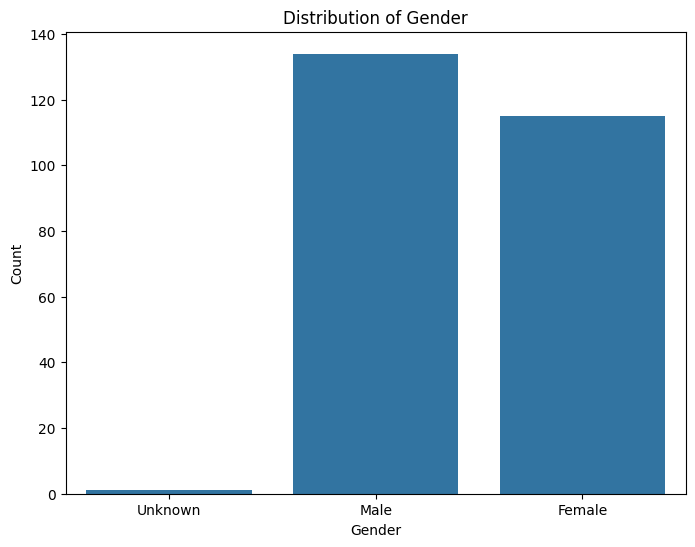

In [8]:
# Visualize the distribution
# label dictionary
label_dict = {
    0: "Unknown",
    1: "Male",
    2: "Female"}

plt.figure(figsize=(8, 6))
sns.countplot(data=df_data, x="app_demographic.1.player.gender")
# add labels
plt.xlabel("Gender")
plt.ylabel("Count") 
# add legend 
plt.xticks(ticks=[0, 1, 2], labels=[label_dict[i] for i in range(3)])
plt.title("Distribution of Gender")

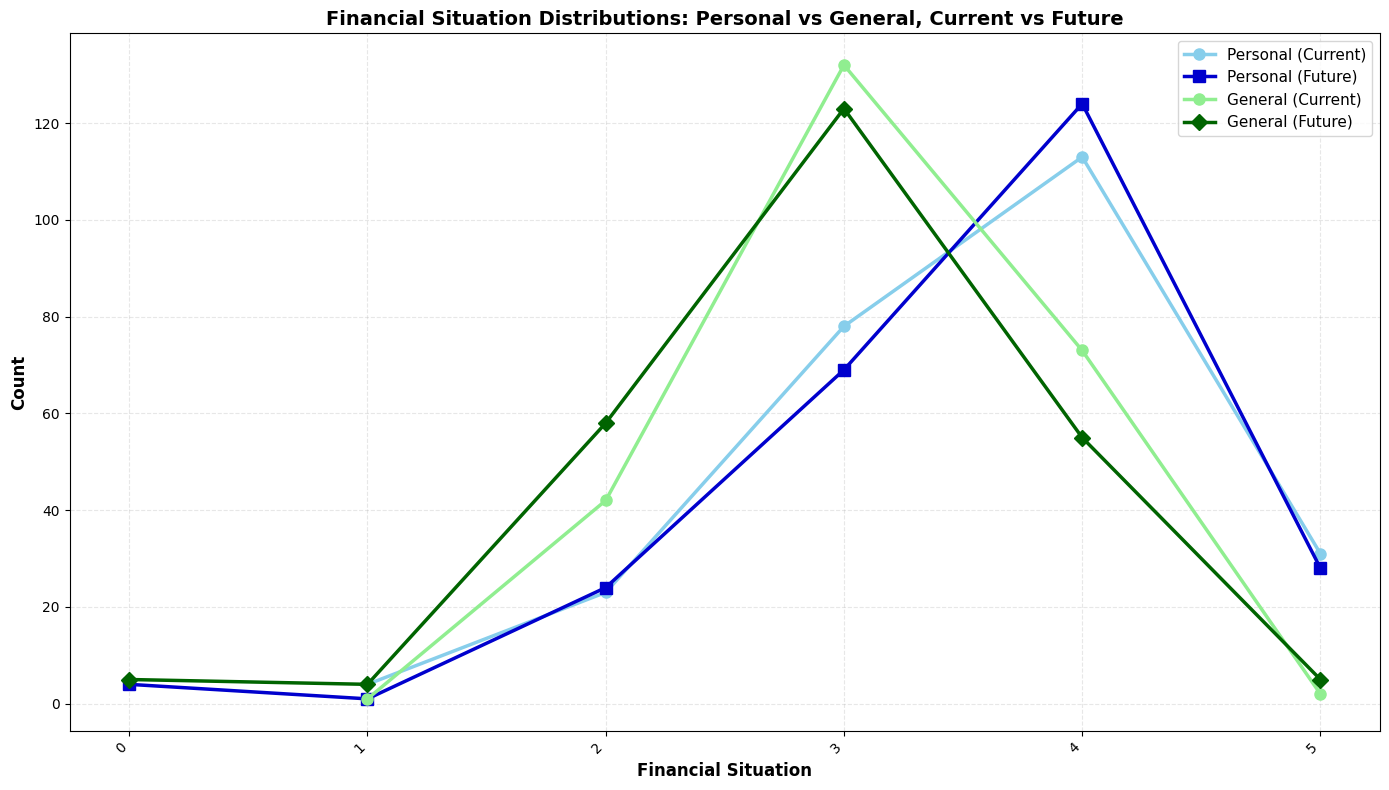

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create figure
plt.figure(figsize=(14, 8))

# Define colors
colors = {
    'personal_current': '#87CEEB',    # Light blue
    'personal_future': '#0000CD',     # Dark blue
    'general_current': '#90EE90',     # Light green
    'general_future': '#006400'       # Dark green
}

# Get value counts for each variable
personal_current = df_data["app_demographic.1.player.financial_situation_personal_current"].value_counts().sort_index()
personal_future = df_data["app_demographic.1.player.financial_situation_personal_future"].value_counts().sort_index()
general_current = df_data["app_demographic.1.player.financial_situation_general_current"].value_counts().sort_index()
general_future = df_data["app_demographic.1.player.financial_situation_general_future"].value_counts().sort_index()

# Plot lines
plt.plot(personal_current.index, personal_current.values, marker='o', linewidth=2.5, 
         color=colors['personal_current'], label='Personal (Current)', markersize=8)
plt.plot(personal_future.index, personal_future.values, marker='s', linewidth=2.5, 
         color=colors['personal_future'], label='Personal (Future)', markersize=8)
plt.plot(general_current.index, general_current.values, marker='o', linewidth=2.5, 
         color=colors['general_current'], label='General (Current)', markersize=8)
plt.plot(general_future.index, general_future.values, marker='D', linewidth=2.5, 
         color=colors['general_future'], label='General (Future)', markersize=8)

# Customize plot
plt.xlabel('Financial Situation', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Financial Situation Distributions: Personal vs General, Current vs Future', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

<positron-console-cell-10>:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


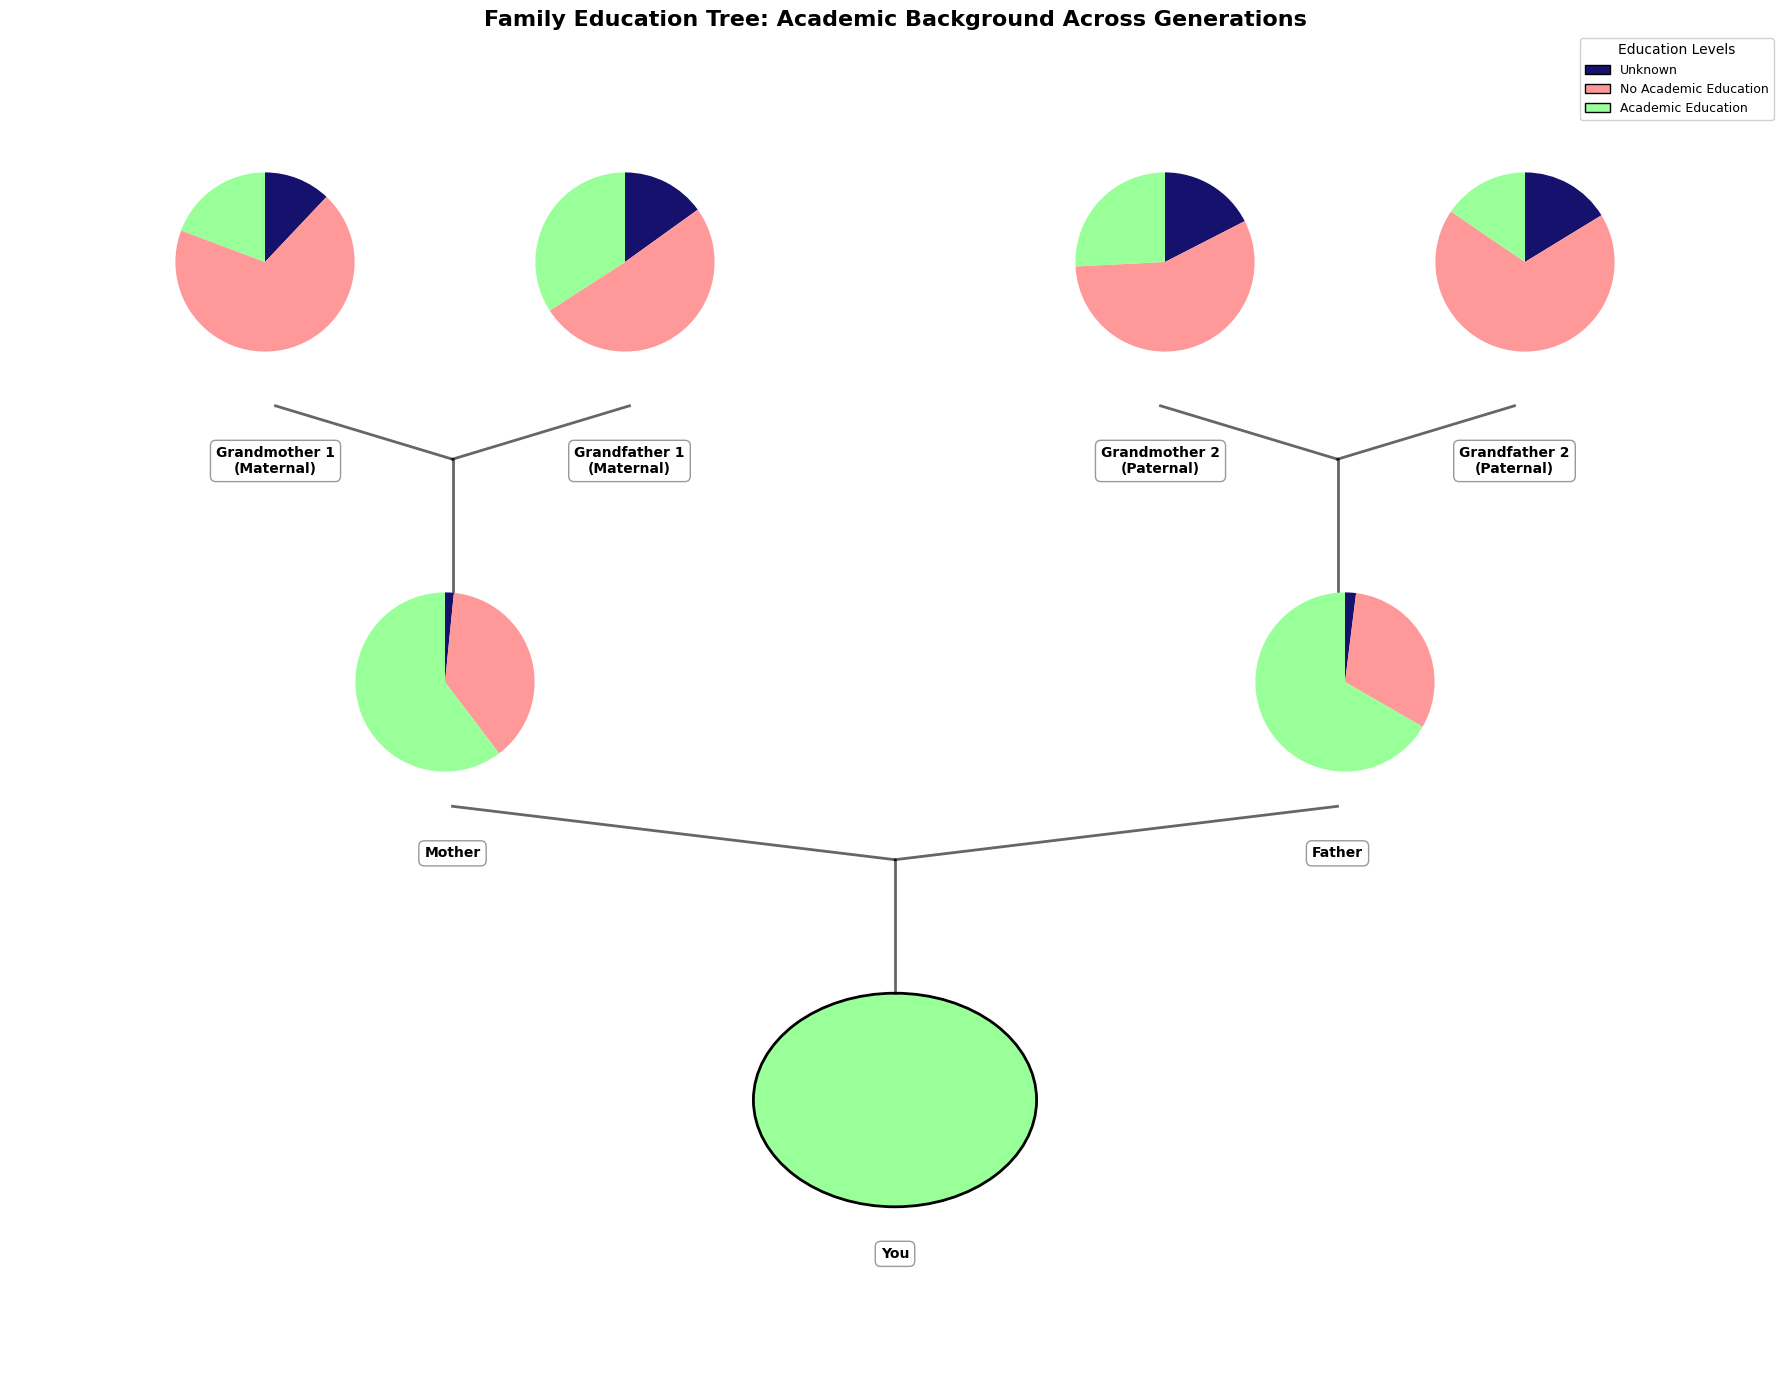

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np
import pandas as pd

def create_family_tree_with_distributions(df_data):
    """
    Create a genealogical tree with education distribution pie charts at each node
    """
    
    # Define the variables
    vars_dict = {
        'Grandmother 1\n(Maternal)': 'app_demographic.1.player.edu_family_2gen_f1',
        'Grandfather 1\n(Maternal)': 'app_demographic.1.player.edu_family_2gen_m1',
        'Grandmother 2\n(Paternal)': 'app_demographic.1.player.edu_family_2gen_f2',
        'Grandfather 2\n(Paternal)': 'app_demographic.1.player.edu_family_2gen_m2',
        'Mother': 'app_demographic.1.player.edu_family_1gen_f',
        'Father': 'app_demographic.1.player.edu_family_1gen_m'
    }
    
    # Calculate distributions for each variable
    distributions = {}
    for label, col in vars_dict.items():
        if col in df_data.columns:
            value_counts = df_data[col].value_counts(normalize=True).sort_index()
            distributions[label] = value_counts
        else:
            print(f"Warning: {col} not found in dataframe")
            distributions[label] = pd.Series()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 14))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Define positions for family tree
    # Generation 2 (Grandparents) - top level
    positions = {
        'Grandmother 1\n(Maternal)': (1.5, 8),
        'Grandfather 1\n(Maternal)': (3.5, 8),
        'Grandmother 2\n(Paternal)': (6.5, 8),
        'Grandfather 2\n(Paternal)': (8.5, 8),
        # Generation 1 (Parents) - middle level
        'Mother': (2.5, 5),
        'Father': (7.5, 5),
        # Generation 0 (Player) - bottom level
        'You': (5, 2)
    }
    
    # Draw connections
    # Maternal grandparents to mother
    ax.plot([2.5, 2.5], [6.8, 5.8], 'k-', linewidth=2, alpha=0.6)
    ax.plot([1.5, 2.5], [7.2, 6.8], 'k-', linewidth=2, alpha=0.6)
    ax.plot([3.5, 2.5], [7.2, 6.8], 'k-', linewidth=2, alpha=0.6)
    
    # Paternal grandparents to father
    ax.plot([7.5, 7.5], [6.8, 5.8], 'k-', linewidth=2, alpha=0.6)
    ax.plot([6.5, 7.5], [7.2, 6.8], 'k-', linewidth=2, alpha=0.6)
    ax.plot([8.5, 7.5], [7.2, 6.8], 'k-', linewidth=2, alpha=0.6)
    
    # Parents to player
    ax.plot([5, 5], [3.8, 2.8], 'k-', linewidth=2, alpha=0.6)
    ax.plot([2.5, 5], [4.2, 3.8], 'k-', linewidth=2, alpha=0.6)
    ax.plot([7.5, 5], [4.2, 3.8], 'k-', linewidth=2, alpha=0.6)
    
    # Red and green colors for pie charts, grey for not available

    colors = ['#16116d','#ff9999','#99ff99']
    
    # Get all unique education levels across all variables
    all_levels = set()
    for dist in distributions.values():
        all_levels.update(dist.index)
    all_levels = sorted(list(all_levels))
    
    # Create color mapping
    color_map = {level: colors[i % len(colors)] for i, level in enumerate(all_levels)}
    
    # Draw pie charts at each node
    pie_radius = 0.8
    
    for label, pos in positions.items():
        if label == 'Player':
            # Just draw a circle for player
            circle = Circle(pos, pie_radius, facecolor='#99ff99', edgecolor='ff9999', 
                          linewidth=3, alpha=0.7)
            ax.add_patch(circle)
            ax.text(pos[0], pos[1], 'PLAYER', ha='center', va='center',
                   fontsize=12, fontweight='bold', color='black')
        else:
            # Draw pie chart for family member
            if label in distributions and len(distributions[label]) > 0:
                dist = distributions[label]
                
                # Prepare data for pie
                sizes = dist.values
                pie_colors = [color_map[level] for level in dist.index]
                
                # Create mini pie chart at the position
                # Adjust the axes position to center it properly
                left = (pos[0] - pie_radius) / 10
                bottom = (pos[1] - pie_radius) / 10
                width = (2 * pie_radius) / 10
                height = (2 * pie_radius) / 10
                
                ax_pie = fig.add_axes([left, bottom, width, height])
                wedges, texts = ax_pie.pie(sizes, colors=pie_colors, startangle=90,
                                           counterclock=False)
                ax_pie.set_aspect('equal')
            else:
                # If no data, draw empty circle
                circle = Circle(pos, pie_radius, facecolor='#99ff99', edgecolor='black',
                              linewidth=2, alpha=1.)
                ax.add_patch(circle)
            
            # Add label below
            ax.text(pos[0], pos[1] - 1.1, label, ha='center', va='top',
                   fontsize=10, fontweight='bold', 
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                           edgecolor='gray', alpha=0.8))
    
    # Create legend
    legend_elements = []

    # labels dict for legend
    labels_dict = {
        1 : 'No Academic Education',
        2 : 'Academic Education',
        0 : 'Unknown'
    }


    for level in all_levels:
        legend_elements.append(mpatches.Patch(facecolor=color_map[level], 
                                             edgecolor='black',
                                             label=f'{labels_dict[level]}'))
    
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper right', 
                 title='Education Levels', fontsize=9, 
                 framealpha=0.9, title_fontsize=10)
    
    # Add title
    plt.suptitle('Family Education Tree: Academic Background Across Generations', 
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    return fig

fig = create_family_tree_with_distributions(df_data)

# Save it
plt.savefig('family_edu_tree.png', dpi=300, bbox_inches='tight')
plt.show()

### Study
- Time Work next to time for studies 
- Psychological Variables in Study Context
- Grade Expectation Self vs. Others 


In [11]:
# create dataframe with only demographic columns
df_study = df_data[[col for col in df_data.columns if re.search(r'app_studium', col)]]

### Politics
- LeftRight Self vs. Others 
- Popularity Contest: Beliebtheit Politiker*innen 
- Sonntagsfrage vs. Bundes Polit Barometer 
- Political Efficacy 
- Participation in Demonstrations and Petitions
- Social Networks that are being used

In [12]:
# create dataframe with only demographic columns
df_politics = df_data[[col for col in df_data.columns if re.search(r'app_political', col)]]

In [13]:
# install upsetplot if not already installed
#!sudo python3 -m pip install upsetplot

Found 13 platform columns

Platform usage counts:
Facebook    :   23 (  9.1%)
Twitter     :   44 ( 17.5%)
LinkedIn    :   36 ( 14.3%)
Instagram   :  231 ( 91.7%)
Signal      :   53 ( 21.0%)
YouTube     :  230 ( 91.3%)
Snapchat    :  170 ( 67.5%)
WhatsApp    :  249 ( 98.8%)
TikTok      :  135 ( 53.6%)
Telegram    :   25 (  9.9%)
Discord     :   67 ( 26.6%)
Reddit      :   47 ( 18.7%)
Other       :    0 (  0.0%)


/Users/ramius/.pyenv/versions/3.13.0/envs/py_venv_3.13.0/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/ramius/.pyenv/versions/3.13.0/envs/py_venv_3.13.0/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because th

<Figure size 1500x800 with 0 Axes>

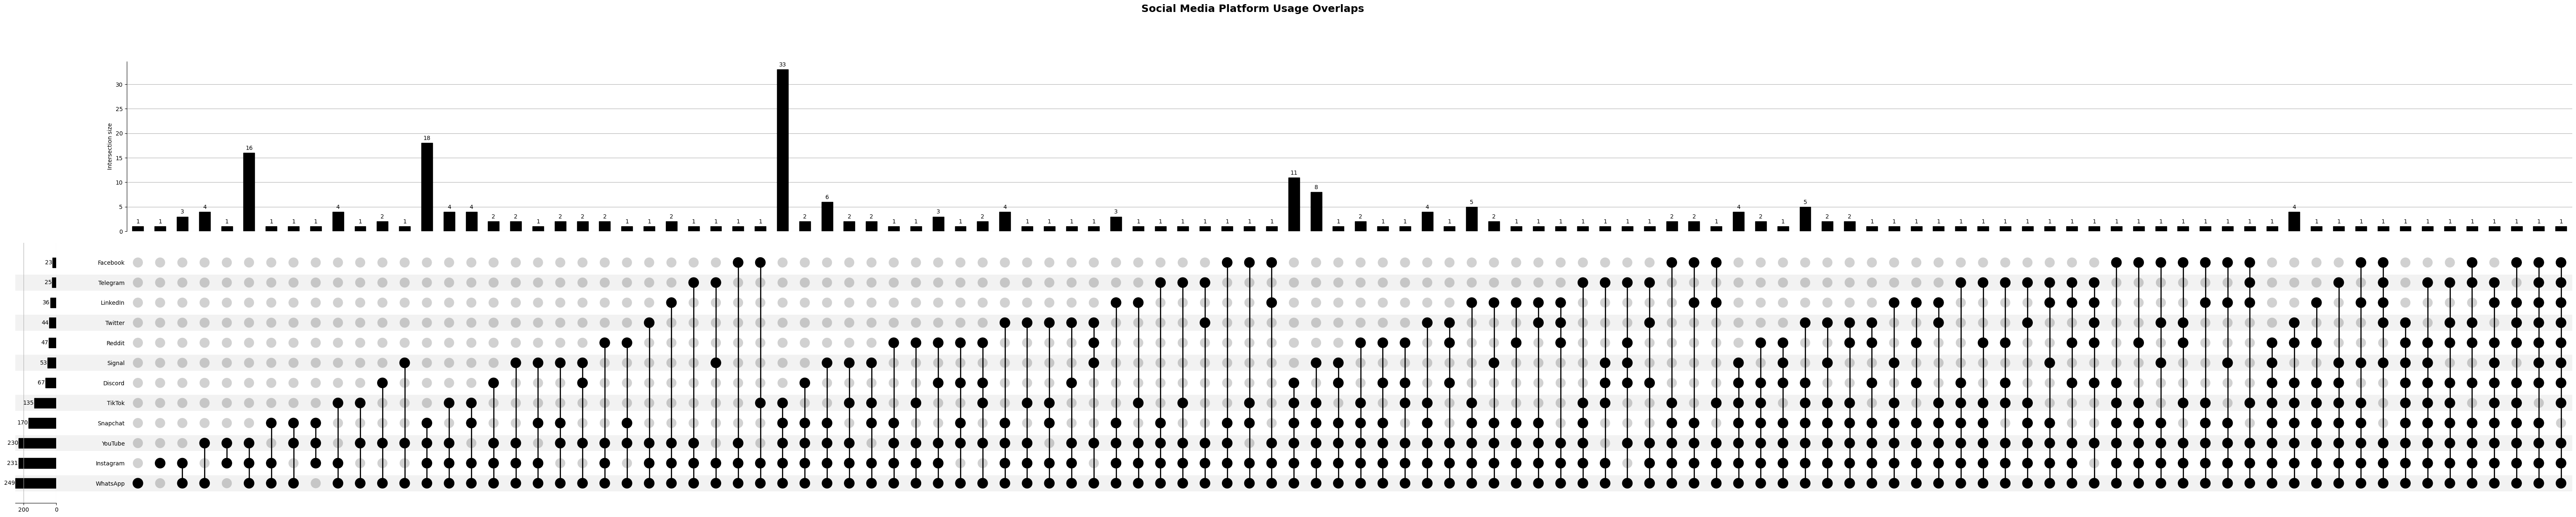


=== Summary ===
Total respondents: 252
Using at least 1 platform: 252 (100.0%)
Using no platforms: 0 (0.0%)
Mean platforms per person: 5.20
Max platforms used: 11


In [14]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

# Define columns with their actual platform names
platform_mapping = {
    'app_political.1.player.social_networks_1': 'Facebook',
    'app_political.1.player.social_networks_2': 'Twitter',
    'app_political.1.player.social_networks_3': 'LinkedIn',
    'app_political.1.player.social_networks_4': 'Instagram',
    'app_political.1.player.social_networks_5': 'Signal',
    'app_political.1.player.social_networks_6': 'YouTube',
    'app_political.1.player.social_networks_7': 'Snapchat',
    'app_political.1.player.social_networks_8': 'WhatsApp',
    'app_political.1.player.social_networks_9': 'TikTok',
    'app_political.1.player.social_networks_10': 'Telegram',
    'app_political.1.player.social_networks_11': 'Discord',
    'app_political.1.player.social_networks_12': 'Reddit',
    'app_political.1.player.social_networks_13': 'Other'
}

# Filter to existing columns
existing_cols = [col for col in platform_mapping.keys() if col in df_data.columns]
print(f"Found {len(existing_cols)} platform columns")

# Create renamed subset with readable names
df_platforms = df_data[existing_cols].rename(columns=platform_mapping)
df_platforms = df_platforms.fillna(0).astype(bool)

# Quick stats
print("\nPlatform usage counts:")
for platform in df_platforms.columns:
    count = df_platforms[platform].sum()
    pct = (count / len(df_platforms)) * 100
    print(f"{platform:12s}: {count:4d} ({pct:5.1f}%)")

# Convert to UpSet format
upset_data = from_indicators(df_platforms.columns.tolist(), data=df_platforms)

# Create UpSet plot
plt.figure(figsize=(15, 8))
upset = UpSet(upset_data, 
              sort_by='degree',
              show_counts=True,
              element_size=50,
              intersection_plot_elements=8)  # Show top 8 intersections
upset.plot()
plt.suptitle('Social Media Platform Usage Overlaps', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n=== Summary ===")
print(f"Total respondents: {len(df_platforms)}")
print(f"Using at least 1 platform: {df_platforms.any(axis=1).sum()} ({df_platforms.any(axis=1).sum()/len(df_platforms)*100:.1f}%)")
print(f"Using no platforms: {(~df_platforms.any(axis=1)).sum()} ({(~df_platforms.any(axis=1)).sum()/len(df_platforms)*100:.1f}%)")
print(f"Mean platforms per person: {df_platforms.sum(axis=1).mean():.2f}")
print(f"Max platforms used: {df_platforms.sum(axis=1).max()}")

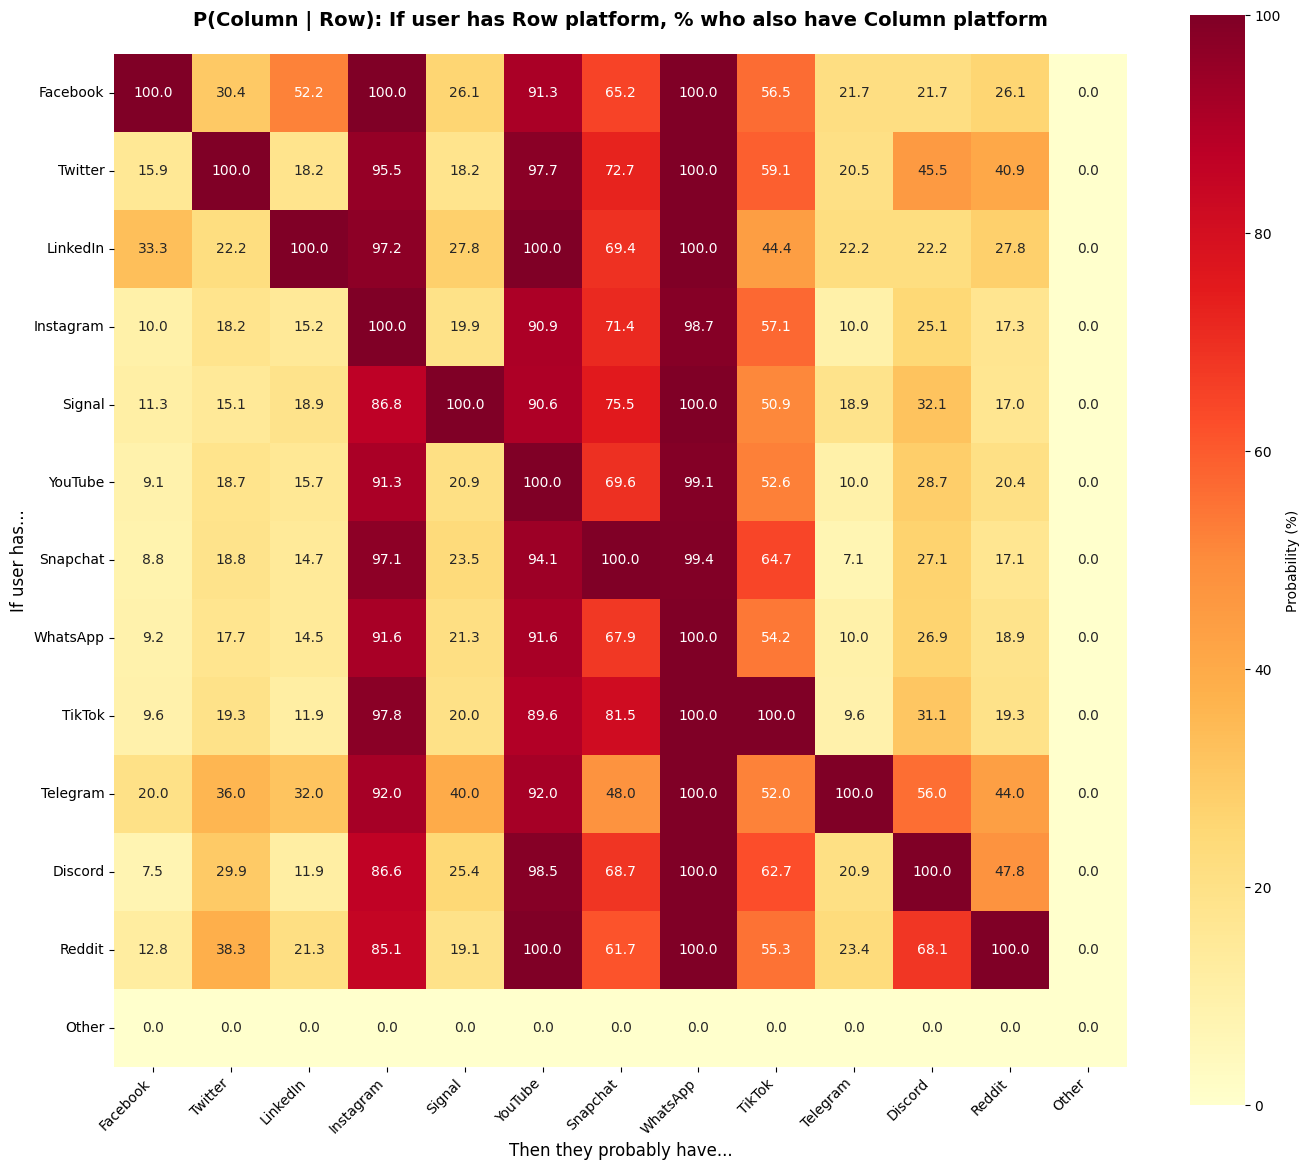

In [15]:
import seaborn as sns
import numpy as np

def create_conditional_probability_matrix(df_bool):
    """Create P(has Y | has X) matrix"""
    
    platforms = df_bool.columns.tolist()
    n = len(platforms)
    
    # P(Y | X) = P(X and Y) / P(X)
    conditional_prob = pd.DataFrame(0.0, index=platforms, columns=platforms)
    
    for x in platforms:
        x_users = df_bool[x].sum()
        if x_users == 0:
            continue
            
        for y in platforms:
            if x == y:
                conditional_prob.loc[x, y] = 100.0  # P(X|X) = 1
            else:
                both = ((df_bool[x]) & (df_bool[y])).sum()
                conditional_prob.loc[x, y] = (both / x_users) * 100
    
    return conditional_prob

# Create and visualize
cond_prob = create_conditional_probability_matrix(df_platforms)

plt.figure(figsize=(14, 12))
sns.heatmap(cond_prob, 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Probability (%)'},
            square=True,
            vmin=0,
            vmax=100)
plt.title('P(Column | Row): If user has Row platform, % who also have Column platform', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Then they probably have...', fontsize=12)
plt.ylabel('If user has...', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Meta
- time taken for survey 
- wordclouds of feedback and network narrative 

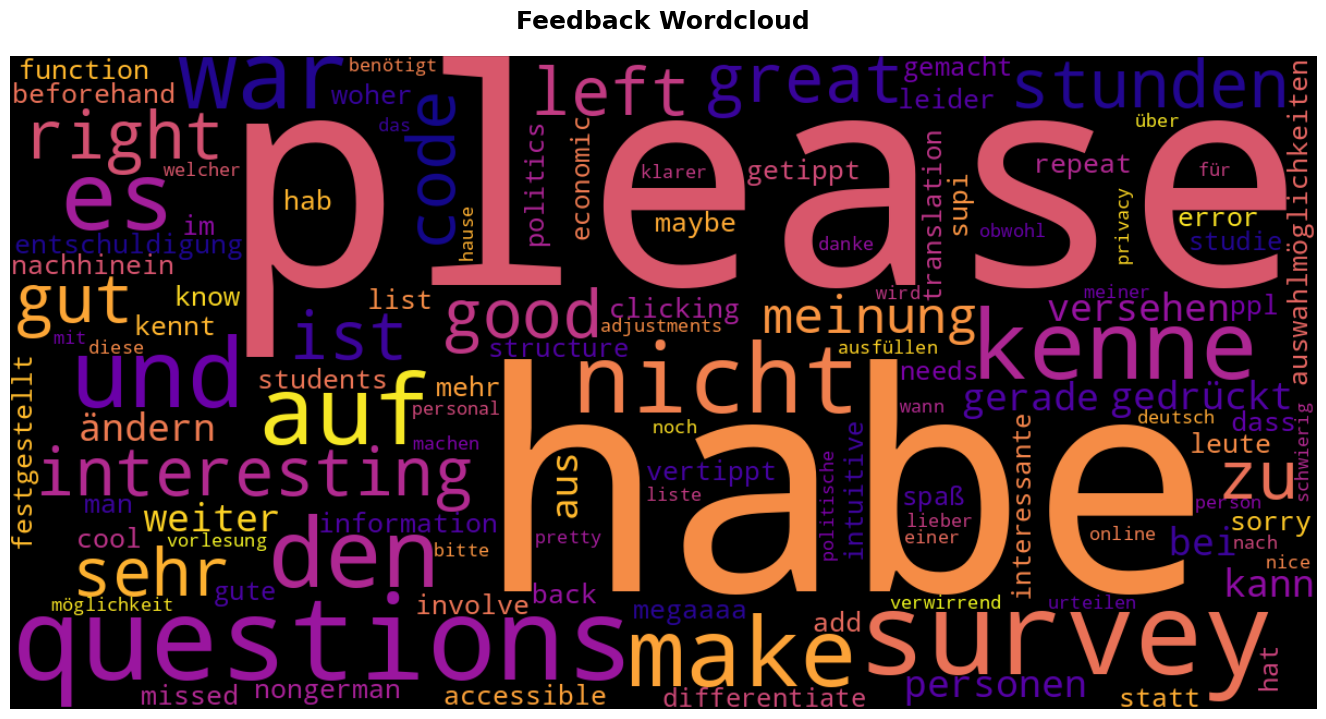

In [16]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# Combine and clean feedback
feedback_text = ' '.join(df_data['app_end.1.player.feedback'].dropna().astype(str).tolist())

# Optional: clean the text
feedback_text = feedback_text.lower()
feedback_text = re.sub(r'[^\w\s]', '', feedback_text)  # remove punctuation

# Custom stopwords for feedback analysis
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['app', 'player', 'game', 'really', 'just', 'like', "die", "ich"])  # add your own

# Generate word cloud
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='black',  # cyberpunk aesthetic
    colormap='plasma',
    max_words=150,
    stopwords=custom_stopwords,
    relative_scaling=0.5,
    collocations=False  # avoid repeated phrases
).generate(feedback_text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Feedback Wordcloud', fontsize=18, fontweight='bold', color='Black', pad=20)
plt.tight_layout(pad=0)

# Save option
# plt.savefig('feedback_wordcloud.png', dpi=300, bbox_inches='tight', facecolor='black')

plt.show()

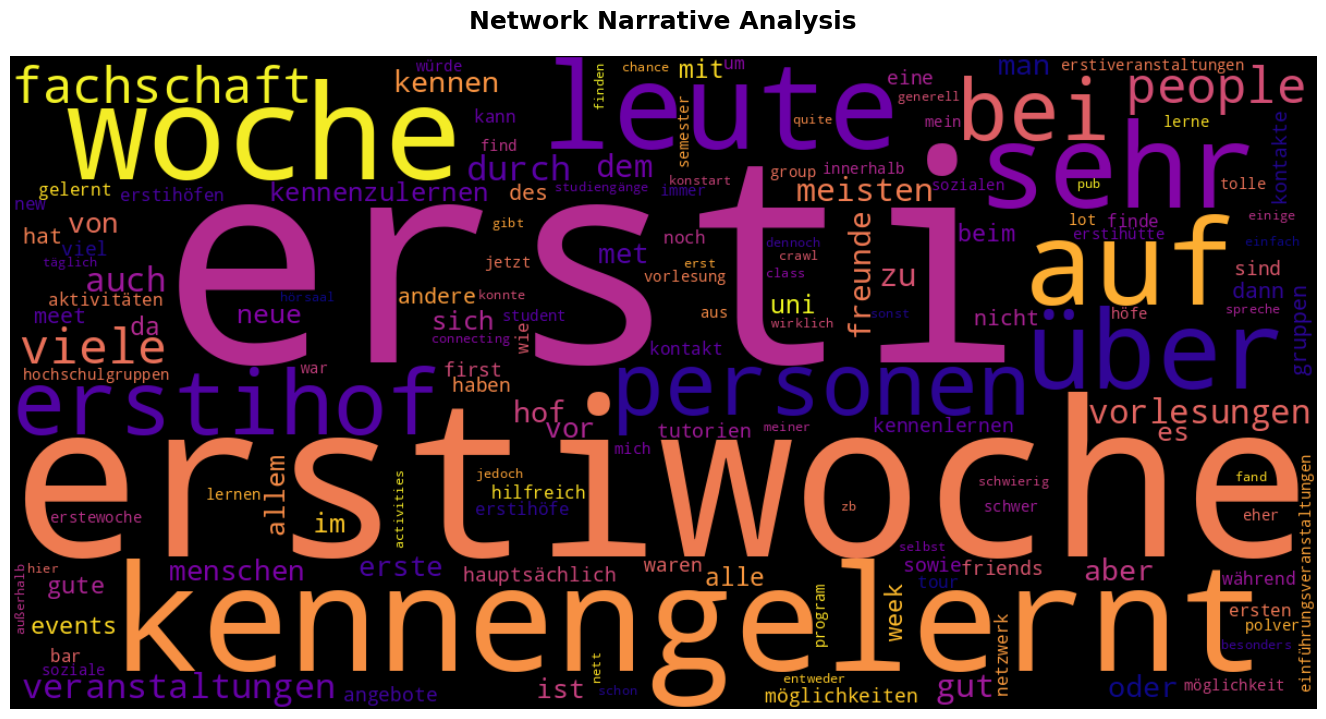

In [17]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# Combine and clean feedback
feedback_text = ' '.join(df_data['app_end.1.player.network_narrative'].dropna().astype(str).tolist())

# Optional: clean the text
feedback_text = feedback_text.lower()
feedback_text = re.sub(r'[^\w\s]', '', feedback_text)  # remove punctuation

# Custom stopwords for feedback analysis
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["den",'app', 'player', 'game', 'really', 'just', 'like', "die", "der", "ich", "und", "habe"])  # add your own

# Generate word cloud
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='black',  # cyberpunk aesthetic
    colormap='plasma',
    max_words=150,
    stopwords=custom_stopwords,
    relative_scaling=0.5,
    collocations=False  # avoid repeated phrases
).generate(feedback_text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Network Narrative Analysis', fontsize=18, fontweight='bold', color='Black', pad=20)
plt.tight_layout(pad=0)

# Save option
# plt.savefig('feedback_wordcloud.png', dpi=300, bbox_inches='tight', facecolor='black')

plt.show()

***
## Motivated Strategies

<positron-console-cell-70>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<positron-console-cell-70>:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


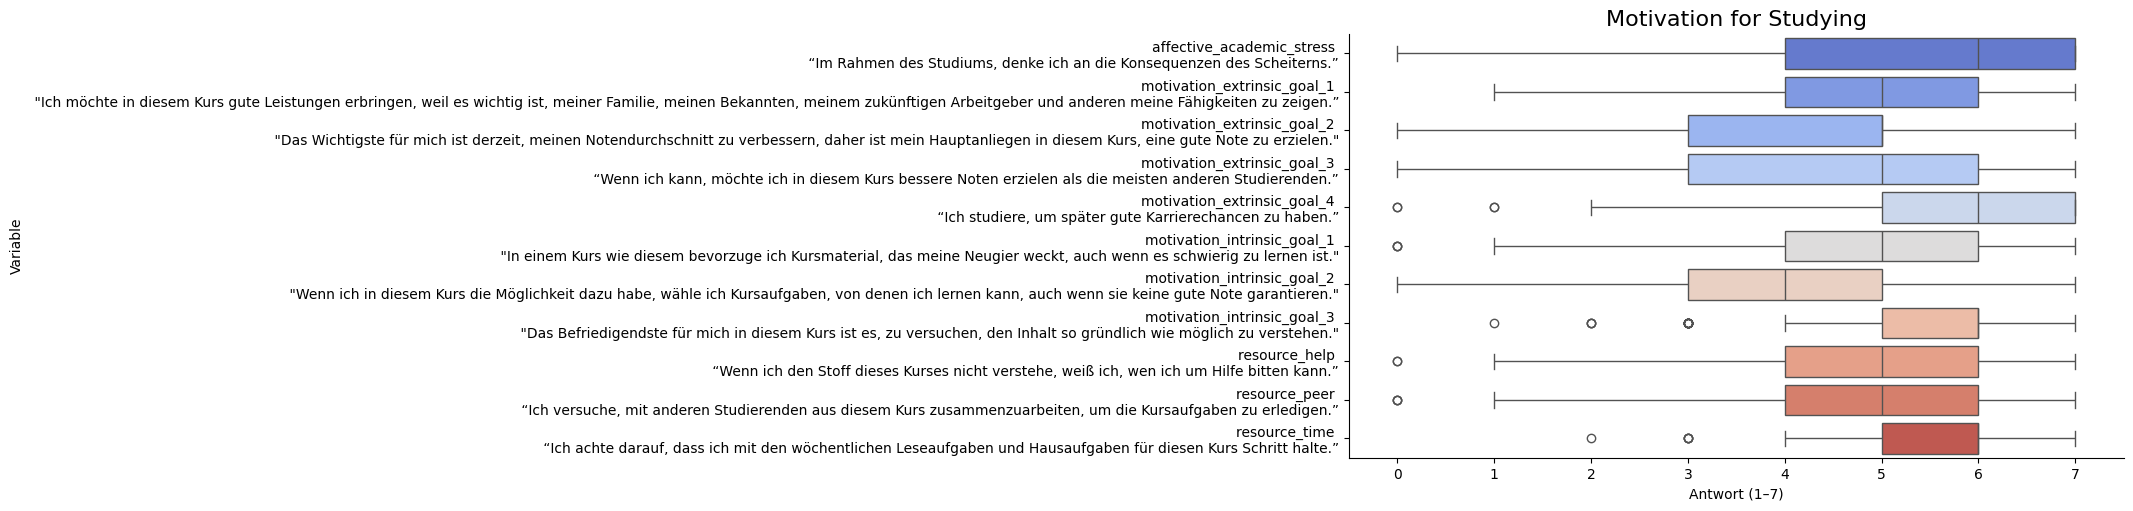

In [70]:
# 1️⃣ Filter for the right questions
df_MS = df_code[df_code["page"] == "MotivatedStrategies"]

# 2️⃣ Extract variable names and German question texts
variables = list(df_MS.variable_name)
questions = df_MS["question_german"].tolist()

# 3️⃣ Combine last element of variable name + German question
labels = [f"{var.split('.')[-1]} \n {q}" for var, q in zip(variables, questions)]

# 4️⃣ Extract corresponding data from df_data
df_MS_data = df_data[variables]

# 5️⃣ Melt to long format
df_melted = df_MS_data.melt(var_name='Variable', value_name='Response')

# 6️⃣ Map variable names to combined labels
label_map = dict(zip(variables, labels))
df_melted['Variable'] = df_melted['Variable'].map(label_map)

# 7️⃣ Sort alphabetically by the last element (the part before " – ")
sorted_labels = sorted(labels, key=lambda x: x.split(" – ")[0])

# 8️⃣ Make Variable a categorical with the sorted order
df_melted['Variable'] = pd.Categorical(df_melted['Variable'], categories=sorted_labels, ordered=True)

# 9️⃣ Plot
plt.figure(figsize=(10, len(labels)*0.5))
sns.boxplot(
    data=df_melted,
    x='Response',
    y='Variable',
    palette='coolwarm',
    orient='h',
    order=sorted_labels
)

plt.title('Motivation for Studying', fontsize=16)
plt.xlabel('Antwort (1–7)')
plt.xlim(-0.5, 7.5)


sns.despine()
plt.tight_layout()
plt.show()


   motivation_intrinsic_goal_1  motivation_extrinsic_goal_1  ...  resource_help  resource_peer
0                          3.0                          1.0  ...            6.0            4.0
1                          3.0                          5.0  ...            2.0            5.0
2                          5.0                          5.0  ...            3.0            4.0
3                          7.0                          6.0  ...            6.0            6.0
4                          6.0                          5.0  ...            5.0            6.0

[5 rows x 11 columns]


<positron-console-cell-69>:20: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix


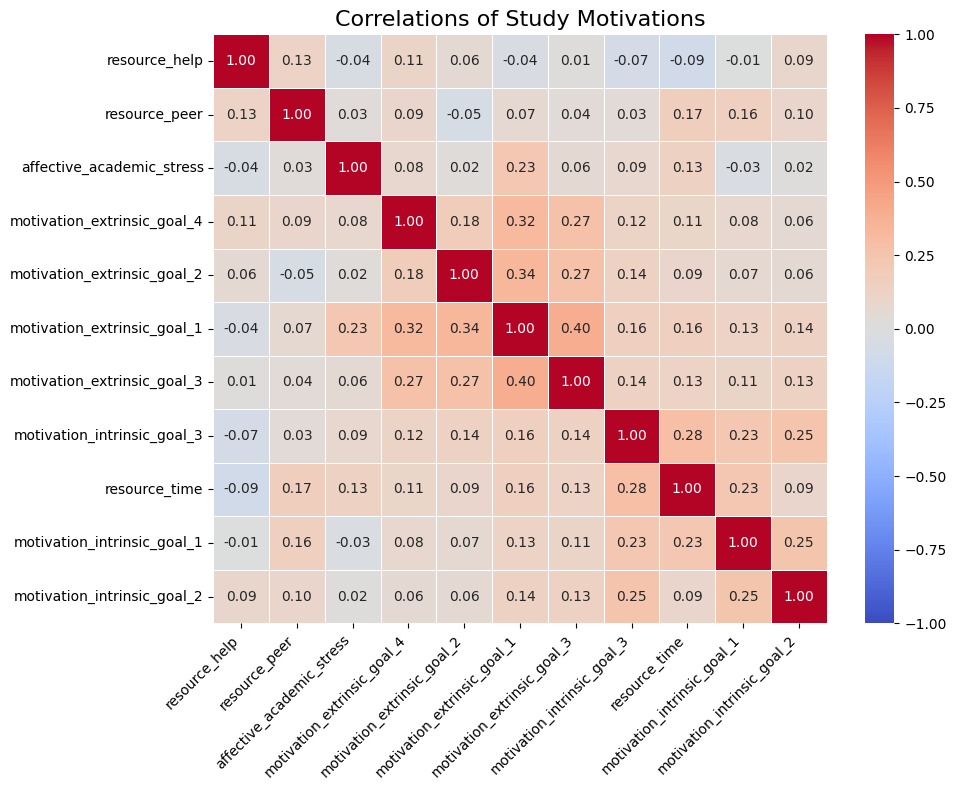

In [69]:
import pandas as pd
import numpy as np
# df_MS_data columns example: ["motivation.Q1", "cogstrategy.Q2", "selfefficacy.Q1"]
df_MS_data_renamed = df_MS_data.copy()

# Take only the part after the last "."
df_MS_data_renamed.columns = [col.split('.')[-1] for col in df_MS_data_renamed.columns]

print(df_MS_data_renamed.head())


# df_MS_data contains only the survey variables
corr_matrix = df_MS_data_renamed.corr()

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

# Convert correlations to distances: distance = 1 - correlation
distance = 1 - corr_matrix
# Hierarchical clustering using 'average' linkage
Z = linkage(distance, method='average')

# Get the order of variables after clustering
cluster_order = leaves_list(Z)
ordered_vars = corr_matrix.columns[cluster_order]

corr_matrix_clustered = corr_matrix.loc[ordered_vars, ordered_vars]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix_clustered,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlations of Study Motivations", fontsize=16)
plt.tight_layout()
plt.show()
